### Speech Tokenization Method Comparison

This script demonstrates two approaches to speech tokenization by processing synthetic audio through codec-inspired and SSL-inspired feature extractors. It visualizes how different feature representations lead to distinct token sequences for the same input signal.

Key Libraries Used:

    numpy: Signal generation and processing

    scipy.signal: FFT computation (implied)

    sklearn.cluster: K-means tokenization

    plotly: Token sequence visualization

Code Logic and Flow

The pipeline:

    Generates dual-tone synthetic speech

    Processes frames through two feature extractors

    Tokenizes features via K-means clustering

    Concatenates token streams

    Visualizes token sequences and alignment
    
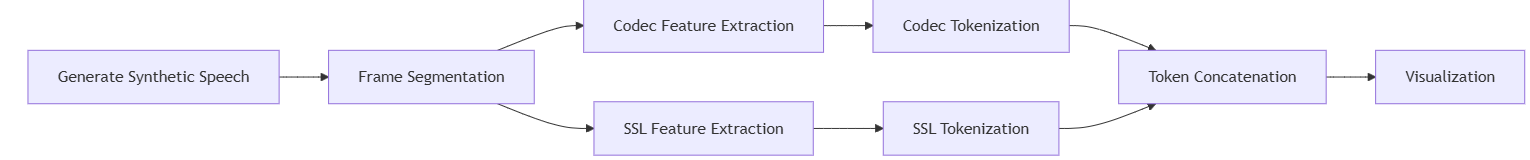

Step-by-Step Code Breakdown

1. Synthetic Audio Generation

    Creates 500ms 440Hz + 880Hz dual-tone signal

    Models harmonic speech-like structure

2. Frame Processing

    25ms frames (400 samples) with 50% overlap

    12.5ms hop maintains temporal resolution

3. Feature Extraction

    Codec-like Features:

        Full FFT magnitude spectrum (0-8kHz)

        Simulates EnCodec spectral analysis

    SSL-like Features:

        Lower FFT band (0-4kHz)

        Logarithmic compression

        Mimics HuBERT's preprocessing

4. Tokenization

    K-means clustering with 8-token vocabulary

    Independent codebooks for each feature type

    Assigns discrete tokens per frame

5. Token Concatenation

    Pairs codec and SSL tokens per frame

    Creates 2D token grid: [time × feature_type]

6. Visualization

    Original Waveform: Shows input signal

    Token Sequences:

        Codec tokens (blue) vs SSL tokens (orange)

        Reveals temporal alignment differences

    Token Grid Heatmap:

        Vertical: Feature type (codec/SSL)

        Horizontal: Frame index

        Color: Token ID (0-7)

Connecting to Lecture Concepts

This implementation demonstrates:

    Feature Extraction Contrast:

        Codec: Full spectral resolution

        SSL: Band-limited perceptual emphasis

    Tokenization Divergence: Same audio → different tokens

    Temporal Alignment: Frame-by-frame comparison

    Vocabulary Design: 8 tokens for extreme compression

    Multi-Stream Tokenization: Combining feature types

    Synthetic Evaluation: Controlled acoustic environment

    Visual Diagnostics:

        Token sequence stability

        Feature-type correlation

    Research Foundations:

        EnCodec vs HuBERT feature philosophies

        Tokenization approaches in SpeechLMs

    SpeechLM Relevance:

        Module 3.1 (speech tokenization)

        Module 3.2 (multi-stream representations)

    Real-World Insight: Feature choice significantly impacts token distributions

    Educational Value: Isolates tokenization from other pipeline complexities

In [4]:
import numpy as np
from sklearn.cluster import KMeans
import scipy.signal as signal
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Set default renderer to browser to avoid nbformat issues
pio.renderers.default = "browser"

# Parameters
#Think of this as preparing the recipe: "We'll make a 0.5s audio clip, split it into 25ms pieces, and convert it to 8 types of symbols."
fs = 16000  # Sampling frequency (Hz)
duration = 0.5  # Duration (seconds)
n_tokens = 8  # Number of tokens for each tokenizer
frame_length = 400  # Samples per frame (25ms at 16kHz)

# Step 1: Generate synthetic audio
    # Makes a beep sound combining:
    #     A 440Hz tone (musical A4 note)
    #     A 880Hz tone (exactly one octave higher)
    # Like a simple musical chord for testing
t = np.linspace(0, duration, int(fs * duration))
audio = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)  # Synthetic signal

# Step 2: Extract features for tokenization
    # Chops audio into 25ms slices (400 samples each)
    # Moves forward 12.5ms (200 samples) each time → 50% overlap
    # Imagine sliding a 25ms window over the audio, moving it 12.5ms each step
frames = np.array([audio[i:i+frame_length] for i in range(0, len(audio) - frame_length, frame_length // 2)])

# Codec-like features (spectral, simulating Encodec)
    # Takes FFT (Fast Fourier Transform) of each frame
    # Keeps magnitude of first half of frequencies (most important part)
    # Simulates how audio codecs like MP3/Opus analyze sound
codec_features = np.abs(np.fft.fft(frames)[:, :frame_length // 2])

# SSL-like features (simplified MFCC-like, simulating HuBERT)
    # Takes FFT but keeps only first quarter of frequencies
    # Applies logarithm (mimics human hearing sensitivity)
    # Simulates Self-Supervised Learning (SSL) features like HuBERT uses
ssl_features = np.log(np.abs(np.fft.fft(frames)[:, :frame_length // 4]) + 1e-10)  # Log-magnitude

# Step 3: Tokenize using k-means
    # K-means groups similar audio frames into 8 categories
    # Each frame gets a token (0-7) based on its features
    # Like sorting candies into 8 color groups, but for sound
codec_kmeans = KMeans(n_clusters=n_tokens, random_state=42)
codec_tokens = codec_kmeans.fit_predict(codec_features)

ssl_kmeans = KMeans(n_clusters=n_tokens, random_state=42)
ssl_tokens = ssl_kmeans.fit_predict(ssl_features)

# Step 4: Concatenate tokens
# Pairs tokens from both feature types:
concatenated_tokens = np.stack((codec_tokens, ssl_tokens), axis=1)  # Shape: (n_frames, 2)

# Step 5: Plot results
# Visualizing Results
# Create subplots with 3 rows and 1 column
fig = make_subplots(rows=3, cols=1,
                    subplot_titles=("Original Audio", "Token Sequences", "Concatenated Tokens"),
                    vertical_spacing=0.08,
                    specs=[[{"secondary_y": False}],
                           [{"secondary_y": False}], 
                           [{"secondary_y": False}]])

# Plot 1: Original Audio
#     Shows the raw waveform of our synthetic beep
fig.add_trace(go.Scatter(x=t, y=audio,
                        mode='lines',
                        name='Original Audio',
                        line=dict(color='blue')),
              row=1, col=1)

# Plot 2: Token Sequences Over Time
#     Shows how codec (blue) and SSL (orange) tokens change over time
#     X-axis converted to seconds using:
#     frame_index * (frame_step / sampling_rate)
time_frames = np.arange(len(codec_tokens)) * (frame_length / 2 / fs)

fig.add_trace(go.Scatter(x=time_frames, y=codec_tokens,
                        mode='lines+markers',
                        name='Codec Tokens',
                        line=dict(color='blue'),
                        marker=dict(size=4)),
              row=2, col=1)

fig.add_trace(go.Scatter(x=time_frames, y=ssl_tokens,
                        mode='lines+markers',
                        name='SSL Tokens',
                        line=dict(color='orange'),
                        marker=dict(size=4)),
              row=2, col=1)

# Plot 3: Token Grid (Heatmap)
#     Visualizes token pairs as colors
#     Rows: Codec vs SSL tokens (0 vs 1)
#     Columns: Time progression of frames
#     Color indicates token ID (0-7)
fig.add_trace(go.Heatmap(z=concatenated_tokens.T,
                        colorscale='viridis',
                        showscale=True,
                        colorbar=dict(title="Token Index", x=1.02)),
              row=3, col=1)

# Update layout
fig.update_layout(height=800,
                  width=1200,
                  title_text="Speech Tokenizer Output",
                  showlegend=True)

# Update x-axis labels
fig.update_xaxes(title_text="Time (s)", row=1, col=1)
fig.update_xaxes(title_text="Time (s)", row=2, col=1)
fig.update_xaxes(title_text="Frame Index", row=3, col=1)

# Update y-axis labels
fig.update_yaxes(title_text="Amplitude", row=1, col=1)
fig.update_yaxes(title_text="Token Index", row=2, col=1)
fig.update_yaxes(title_text="Token Type (0: Codec, 1: SSL)", row=3, col=1)

# Save as HTML (equivalent to savefig)
fig.write_html("speech_tokenizer_output.html")

# Show the plot
fig.show()

# Print sample tokens
print("Codec Tokens (first 10):", codec_tokens[:10])
print("SSL Tokens (first 10):", ssl_tokens[:10])
print("Concatenated Tokens (first 5):", concatenated_tokens[:5])

Codec Tokens (first 10): [7 1 2 1 4 1 6 1 3 1]
SSL Tokens (first 10): [3 1 3 4 3 4 3 4 3 4]
Concatenated Tokens (first 5): [[7 3]
 [1 1]
 [2 3]
 [1 4]
 [4 3]]
